# 📍 01 — VỊ TRÍ (Location) · bộ TP.HCM

Bóc tách ảnh hưởng của **khu vực** tới **giá** và **hệ số nhân**. (3 khu: Crescent Mall · SC Vivo
City · EcoGreen Sài Gòn)

> Nguyên tắc: giá bị quãng đường chi phối → so sánh phải **kiểm soát quãng đường** trước.

In [1]:
import sys; sys.path.insert(0, ".")
from _common import *
setup()
df = load(frac=0.15)   # doi frac=1.0 de nap toan bo

Nap 1,034,550 dong (mau 15%) | gia median 114k VND | surge 81.7%


## 1. Chân dung 3 khu

In [2]:
loc = df.groupby("pickup_location_name").agg(
    so_dong=(PRICE,"size"), gia_median_k=("price_k","median"),
    surge_rate=("is_surge","mean"), surge_mean=(SURGE,"mean"),
    quang_duong_km=("quote_distance","median"), phut_per_km=("dur_per_km","median"),
    toc_do_kmh=("speed_kmh","median")).round(2)
display(loc)
print(f"eta(khu, GIA)={eta(df.pickup_location_name, df[PRICE]):.3f} | "
      f"eta(khu, SURGE)={eta(df.pickup_location_name, df[SURGE]):.3f}")

,so_dong,gia_median_k,surge_rate,surge_mean,quang_duong_km,phut_per_km,toc_do_kmh
pickup_location_name,,,,,,,
Crescent Mall,349202,98.0,0.74,1.10,5.63,3.37,17.83
EcoGreen Sài Gòn,333210,127.0,0.88,1.23,6.50,4.08,14.71
SC Vivo City,352138,123.0,0.82,1.17,7.25,3.49,17.21


eta(khu, GIA)=0.292 | eta(khu, SURGE)=0.299


## 2. Giá & surge theo khu

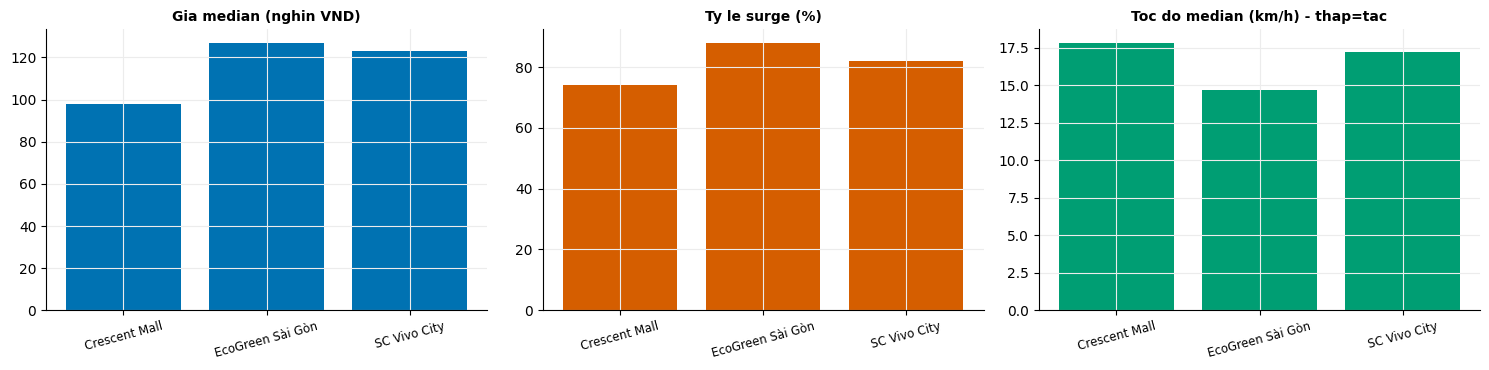

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
ax[0].bar(range(len(loc)), loc.gia_median_k, color=BLUE)
ax[0].set_title("Gia median (nghin VND)", fontweight="bold", fontsize=10)
ax[1].bar(range(len(loc)), loc.surge_rate*100, color=RED)
ax[1].set_title("Ty le surge (%)", fontweight="bold", fontsize=10)
ax[2].bar(range(len(loc)), loc.toc_do_kmh, color=GREEN)
ax[2].set_title("Toc do median (km/h) - thap=tac", fontweight="bold", fontsize=10)
for a in ax: a.set_xticks(range(len(loc))); a.set_xticklabels(loc.index, rotation=15, fontsize=8.5)
plt.tight_layout(); plt.show()

## 3. Premium THẬT — kiểm soát quãng đường

Không so giá thô. Chia cùng dải quãng đường rồi so giá median giữa các khu.

In [4]:
df["dbin"] = binned(df.quote_distance, 6)
pv = df.pivot_table(index="dbin", columns="pickup_location_name", values="price_k", aggfunc="median")
display(pv.round(1))
# bien do chenh that giua khu, trong tung dai quang duong
spread = (pv.max(axis=1) - pv.min(axis=1)) / pv.min(axis=1) * 100
print(f"Chenh gia giua khu (trong cung dai q.duong): trung binh {spread.mean():.1f}%")

pickup_location_name,Crescent Mall,EcoGreen Sài Gòn,SC Vivo City
dbin,,,
"(1.112, 5.018]",77.0,81.0,61.0
"(5.018, 5.606]",94.0,108.0,102.0
"(5.606, 6.17]",100.0,116.0,108.0
"(6.17, 7.555]",111.0,128.0,120.0
"(7.555, 8.484]",126.0,149.0,137.0
"(8.484, 45.0]",157.0,170.0,159.0


Chenh gia giua khu (trong cung dai q.duong): trung binh 17.6%


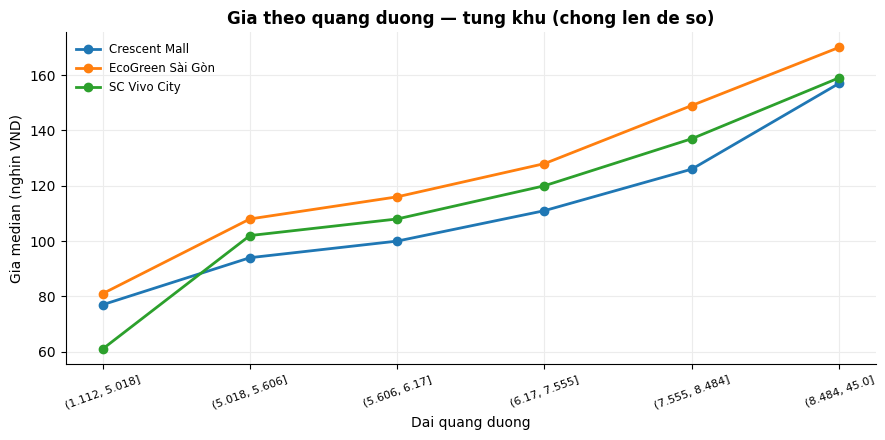

In [5]:
fig, ax = plt.subplots(figsize=(9,4.5))
for khu in pv.columns:
    ax.plot(range(len(pv)), pv[khu], marker="o", lw=2, label=khu)
ax.set_xticks(range(len(pv))); ax.set_xticklabels(pv.index, rotation=20, fontsize=8)
ax.set_ylabel("Gia median (nghin VND)"); ax.set_xlabel("Dai quang duong")
ax.set_title("Gia theo quang duong — tung khu (chong len de so)", fontweight="bold")
ax.legend(frameon=False, fontsize=8.5); plt.tight_layout(); plt.show()

## 4. Heatmap Khu × Giờ (tỷ lệ surge)

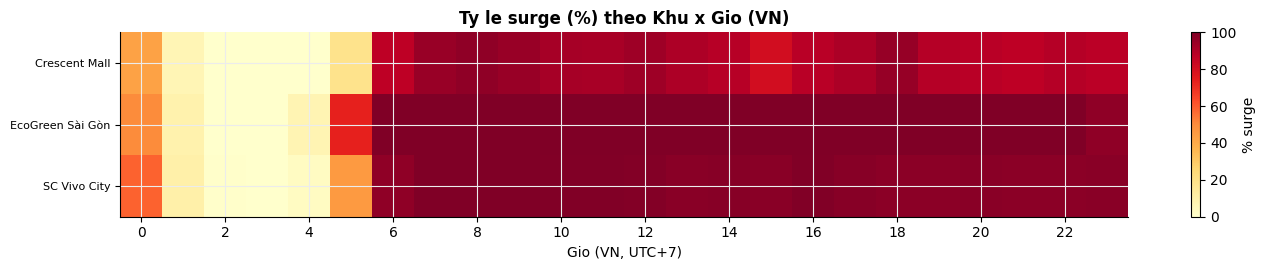

In [6]:
hm = df.pivot_table(index="pickup_location_name", columns="gio_vn", values="is_surge", aggfunc="mean")*100
fig, ax = plt.subplots(figsize=(14, 2.8))
im = ax.imshow(hm.values, aspect="auto", cmap="YlOrRd")
ax.set_yticks(range(len(hm))); ax.set_yticklabels(hm.index, fontsize=8)
ax.set_xticks(range(0,24,2)); ax.set_xticklabels(range(0,24,2))
ax.set_xlabel("Gio (VN, UTC+7)"); ax.set_title("Ty le surge (%) theo Khu x Gio (VN)", fontweight="bold")
plt.colorbar(im, ax=ax, label="% surge"); plt.tight_layout(); plt.show()

## Kết luận — Vị trí

- **→ Giá:** ảnh hưởng vừa; phần lớn chênh giá giữa khu là do **cơ cấu quãng đường**, sau kiểm
  soát còn lại vừa phải.
- **→ Hệ số nhân:** khu vực ảnh hưởng rõ (η ~0,3) — mạnh hơn Boston (~0,15). Mỗi khu có mức khan
  hiếm xe & giờ cao điểm riêng (xem heatmap).
- ⚠️ Chỉ 3 khu nên kết luận về vị trí còn hạn chế so với Boston (12 khu).